# Implementación de Regresión Softmax (Multinomial) con PyTorch

<a href="https://colab.research.google.com/github/andrescastro-itm/pytorch_resources/blob/main/5_RegresionSoftmax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook, implementaremos una regresión softmax (regresión logística multinomial) utilizando PyTorch, aplicada al clásico conjunto de datos **MNIST** (dígitos escritos a mano). Seguiremos estos pasos:

1. Cargar el conjunto de datos MNIST usando `Dataset` y `DataLoader`
2. Definir el modelo de regresión softmax usando la API de PyTorch
3. Implementar el proceso de entrenamiento
4. Evaluar el modelo
5. Visualizar predicciones y probabilidades
6. Analizar el modelo entrenado
7. Realizar predicciones individuales


In [1]:
# Importamos las bibliotecas necesarias
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Configuramos la semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# Configuramos matplotlib
%matplotlib inline
plt.style.use('ggplot')

## 1. Carga del Conjunto de Datos MNIST con `Dataset` y `DataLoader`

En PyTorch, un **`Dataset`** es un objeto que sabe *cómo acceder* a un solo ejemplo (una imagen y su etiqueta), mientras que un **`DataLoader`** se encarga de *agrupar* esos ejemplos en lotes (`batches`), barajarlos (`shuffle`) y entregarlos de forma eficiente durante el entrenamiento (incluso en paralelo, con varios `workers`).

`torchvision.datasets.MNIST` ya implementa la interfaz `Dataset` por nosotros: descarga las imágenes, las indexa y nos permite aplicarles transformaciones (`transform`) como convertirlas a tensores y normalizarlas.


In [2]:
# Definimos las transformaciones: convertir a tensor y normalizar
transform = transforms.Compose([
    transforms.ToTensor(),                       # Convierte la imagen PIL a tensor [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))   # Normaliza con la media/std de MNIST
])

# Descargamos (o cargamos si ya existen) los conjuntos de entrenamiento y prueba
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Ejemplos de entrenamiento: {len(train_dataset)}")
print(f"Ejemplos de prueba: {len(test_dataset)}")
print(f"Forma de una imagen: {train_dataset[0][0].shape}")  # [canales, alto, ancho]
print(f"Número de clases: {len(train_dataset.classes)}")


Ejemplos de entrenamiento: 60000
Ejemplos de prueba: 10000
Forma de una imagen: torch.Size([1, 28, 28])
Número de clases: 10


## 2. Creación de los `DataLoader`

Con el `Dataset` ya definido, creamos los `DataLoader`. Estos nos permiten iterar el conjunto de datos en mini-batches, lo cual es clave para el entrenamiento por **descenso de gradiente estocástico (SGD)**: en lugar de calcular el gradiente con todo el dataset (lento) o con un solo ejemplo (ruidoso), lo hacemos con pequeños lotes.


Forma del batch de imágenes: torch.Size([100, 1, 28, 28])
Forma del batch de etiquetas: torch.Size([100])


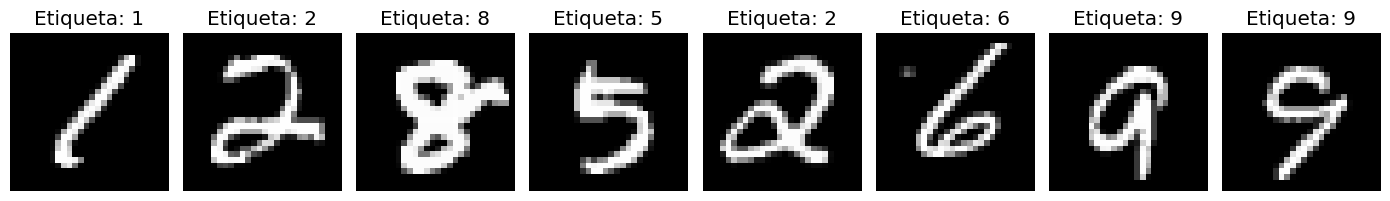

In [3]:
# Creamos los DataLoaders
batch_size = 100

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Visualizamos un batch de ejemplo
imagenes, etiquetas = next(iter(train_loader))
print(f"Forma del batch de imágenes: {imagenes.shape}")  # [batch, 1, 28, 28]
print(f"Forma del batch de etiquetas: {etiquetas.shape}")

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    axes[i].imshow(imagenes[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Etiqueta: {etiquetas[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## 3. Definición del Modelo de Regresión Softmax

Al igual que en la regresión logística, definimos nuestro modelo como una clase que hereda de `nn.Module`. La diferencia clave es que la capa lineal ahora produce **10 salidas** (una por cada dígito, 0-9) en lugar de una sola.

> **Nota importante:** en la práctica, `nn.CrossEntropyLoss` de PyTorch ya incluye internamente el cálculo de `log-softmax` (por estabilidad numérica). Por eso el `forward()` del modelo devuelve los **logits** (la salida lineal, sin softmax aplicado). La función softmax la aplicaremos manualmente solo cuando queramos *interpretar* las probabilidades (por ejemplo, al visualizar resultados).


In [4]:
class RegresionSoftmax(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RegresionSoftmax, self).__init__()
        # Capa lineal: produce un "logit" (puntaje) por cada clase
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        # Aplanamos la imagen 28x28 a un vector de 784 valores
        x = x.view(x.size(0), -1)
        # Aplicamos la transformación lineal -> logits (sin softmax)
        logits = self.linear(x)
        return logits

# Instanciamos el modelo
input_size = 28 * 28   # 784 píxeles por imagen
num_classes = 10        # dígitos 0-9
modelo = RegresionSoftmax(input_size, num_classes)
print(modelo)


RegresionSoftmax(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


## 4. Implementación del Proceso de Entrenamiento

Definimos la función de pérdida (**Cross-Entropy multicategórica**) y el optimizador. Gracias al `DataLoader`, el loop de entrenamiento se simplifica: ya no necesitamos barajar ni cortar los datos en batches manualmente.


Época [1/10], Pérdida: 0.3662
Época [2/10], Pérdida: 0.3036
Época [3/10], Pérdida: 0.2921
Época [4/10], Pérdida: 0.2864
Época [5/10], Pérdida: 0.2820
Época [6/10], Pérdida: 0.2785
Época [7/10], Pérdida: 0.2753
Época [8/10], Pérdida: 0.2737
Época [9/10], Pérdida: 0.2719
Época [10/10], Pérdida: 0.2705


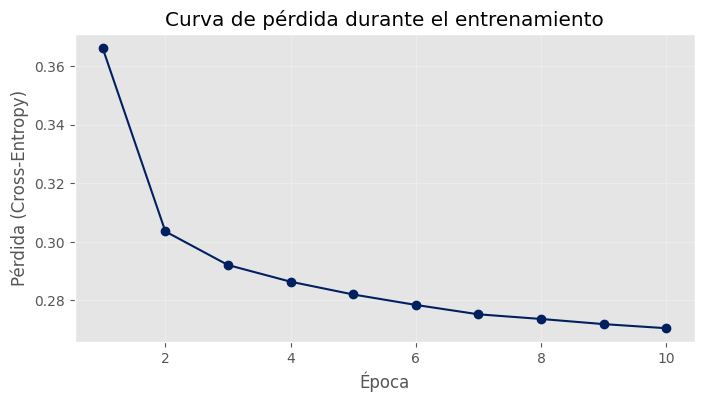

In [5]:
# Definimos la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()  # Aplica log-softmax + NLLLoss internamente
optimizer = optim.SGD(modelo.parameters(), lr=0.1)

num_epochs = 10
losses = []  # Para guardar el historial de pérdida

# Entrenamiento del modelo
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for imagenes_batch, etiquetas_batch in train_loader:
        # Forward pass: obtenemos los logits
        logits = modelo(imagenes_batch)
        loss = criterion(logits, etiquetas_batch)

        # Backward pass y actualización de parámetros
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Época [{epoch+1}/{num_epochs}], Pérdida: {avg_loss:.4f}")

# Visualizamos la curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), losses, marker='o', color='#002060')
plt.xlabel('Época')
plt.ylabel('Pérdida (Cross-Entropy)')
plt.title('Curva de pérdida durante el entrenamiento')
plt.grid(alpha=0.3)
plt.show()


## 5. Evaluación del Modelo

Evaluamos el modelo en el conjunto de prueba calculando la exactitud (`accuracy`) global. Para predecir la clase final, tomamos el índice del logit más alto (`argmax`), que es equivalente a tomar la clase con mayor probabilidad softmax.


In [6]:
# Evaluamos el modelo
modelo.eval()  # Cambiamos a modo evaluación

correctos = 0
total = 0

with torch.no_grad():  # No necesitamos calcular gradientes durante la evaluación
    for imagenes_batch, etiquetas_batch in test_loader:
        logits = modelo(imagenes_batch)
        # argmax(logits) == argmax(softmax(logits)) -> no es necesario aplicar softmax para predecir
        _, predicciones = torch.max(logits, dim=1)

        total += etiquetas_batch.size(0)
        correctos += (predicciones == etiquetas_batch).sum().item()

accuracy = correctos / total
print(f"Exactitud (accuracy) en el conjunto de prueba: {accuracy:.4f}")


Exactitud (accuracy) en el conjunto de prueba: 0.9205


## 6. Visualización de Predicciones y Probabilidades Softmax

Veamos algunas predicciones individuales junto con la distribución de probabilidad completa generada por la función **softmax** sobre los 10 logits.


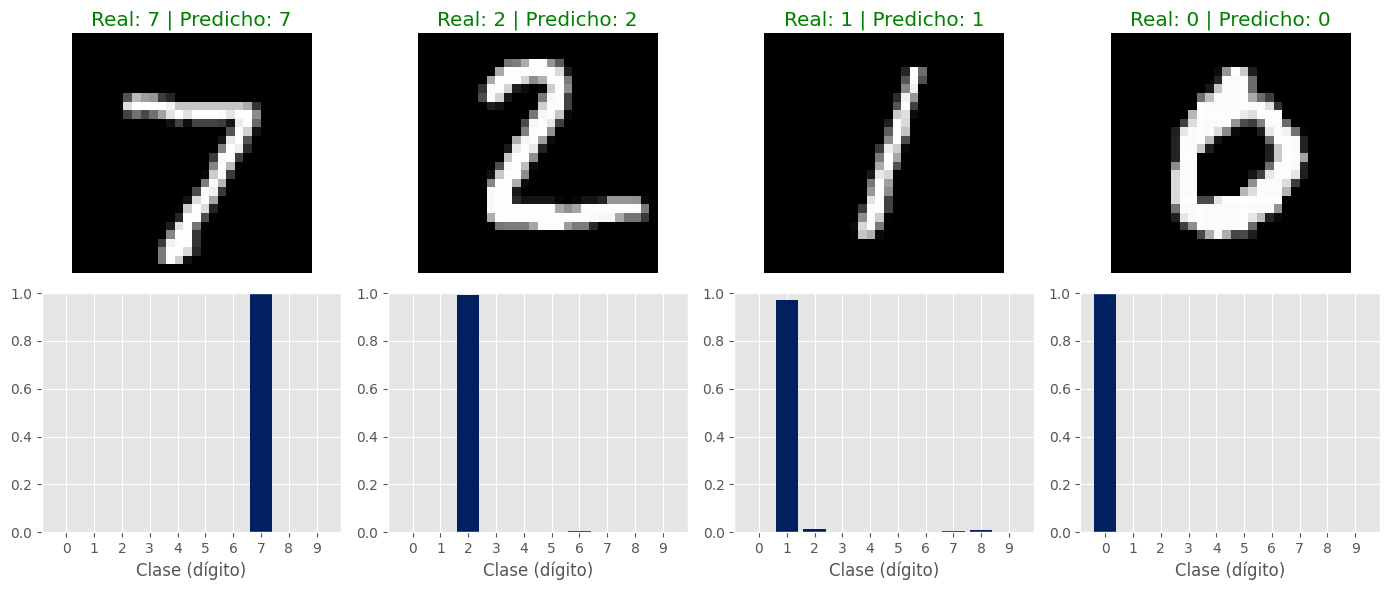

In [7]:
# Tomamos un batch de prueba
imagenes_batch, etiquetas_batch = next(iter(test_loader))

with torch.no_grad():
    logits = modelo(imagenes_batch)
    probabilidades = torch.softmax(logits, dim=1)  # Aplicamos softmax para interpretar como probabilidad
    _, predicciones = torch.max(logits, dim=1)

# Visualizamos 4 ejemplos: imagen + barra de probabilidades por clase
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    # Imagen
    axes[0, i].imshow(imagenes_batch[i].squeeze(), cmap='gray')
    color = 'green' if predicciones[i] == etiquetas_batch[i] else 'red'
    axes[0, i].set_title(f"Real: {etiquetas_batch[i].item()} | Predicho: {predicciones[i].item()}", color=color)
    axes[0, i].axis('off')

    # Distribución de probabilidad softmax
    axes[1, i].bar(range(10), probabilidades[i].numpy(), color='#002060')
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel('Clase (dígito)')

plt.tight_layout()
plt.show()


## 7. Análisis del Modelo: de los Logits a la Probabilidad

Tomemos un único ejemplo y veamos paso a paso cómo los logits (salida lineal cruda) se transforman en una distribución de probabilidad mediante softmax: cada valor queda entre 0 y 1, y la suma de los 10 valores es exactamente 1.


In [8]:
# Analizamos un solo ejemplo en detalle
ejemplo_imagen = imagenes_batch[0:1]
ejemplo_etiqueta = etiquetas_batch[0].item()

with torch.no_grad():
    logits_ejemplo = modelo(ejemplo_imagen)
    probas_ejemplo = torch.softmax(logits_ejemplo, dim=1)

print(f"Etiqueta real: {ejemplo_etiqueta}\n")
print("Clase | Logit (z)  | Softmax (probabilidad)")
print("-" * 45)
for clase in range(10):
    print(f"  {clase}   | {logits_ejemplo[0, clase].item():9.4f}  | {probas_ejemplo[0, clase].item():.4f}")

print(f"\nSuma de probabilidades: {probas_ejemplo.sum().item():.4f}  (siempre = 1.0)")
print(f"Clase predicha (argmax): {torch.argmax(probas_ejemplo).item()}")


Etiqueta real: 7

Clase | Logit (z)  | Softmax (probabilidad)
---------------------------------------------
  0   |    0.1472  | 0.0000
  1   |  -13.1363  | 0.0000
  2   |    0.4708  | 0.0000
  3   |    7.3020  | 0.0018
  4   |   -3.0864  | 0.0000
  5   |    0.7533  | 0.0000
  6   |  -11.5107  | 0.0000
  7   |   13.6038  | 0.9981
  8   |    1.5999  | 0.0000
  9   |    4.0353  | 0.0001

Suma de probabilidades: 1.0000  (siempre = 1.0)
Clase predicha (argmax): 7


## 8. Predicciones con el Modelo

Por último, creamos una función de conveniencia para predecir el dígito de una nueva imagen, junto con su nivel de confianza (probabilidad softmax de la clase ganadora).


In [9]:
# Función para realizar predicciones
def predict(modelo, imagen):
    modelo.eval()
    with torch.no_grad():
        if imagen.dim() == 3:
            imagen = imagen.unsqueeze(0)  # Agregamos dimensión de batch si falta
        logits = modelo(imagen)
        probas = torch.softmax(logits, dim=1)
        confianza, clase = torch.max(probas, dim=1)
        return clase.item(), confianza.item()

# Probamos con algunas imágenes del conjunto de prueba
for i in range(5):
    imagen_prueba, etiqueta_real = test_dataset[i]
    clase_predicha, confianza = predict(modelo, imagen_prueba)
    print(f"Real: {etiqueta_real} | Predicho: {clase_predicha} | Confianza: {confianza:.2%}")


Real: 7 | Predicho: 7 | Confianza: 99.81%
Real: 2 | Predicho: 2 | Confianza: 99.07%
Real: 1 | Predicho: 1 | Confianza: 96.93%
Real: 0 | Predicho: 0 | Confianza: 100.00%
Real: 4 | Predicho: 4 | Confianza: 98.13%


## 9. Conclusiones

En este notebook, hemos implementado un modelo de **regresión softmax (multinomial)** utilizando PyTorch sobre el conjunto de datos MNIST. Hemos seguido estos pasos:

1. **Carga de datos**: utilizamos `Dataset` y `DataLoader` de `torchvision` para cargar y servir el conjunto MNIST en mini-batches.
2. **Modelado**: definimos una clase `nn.Module` con una sola capa lineal que produce 10 logits (uno por dígito).
3. **Función de activación softmax**: convierte los logits en una distribución de probabilidad válida (suma = 1), aplicada explícitamente solo para interpretación, ya que `CrossEntropyLoss` la incorpora internamente por estabilidad numérica.
4. **Función de pérdida**: usamos `nn.CrossEntropyLoss`, la generalización multiclase del *log loss*, que penaliza fuertemente cuando el modelo asigna baja probabilidad a la clase correcta.
5. **Entrenamiento**: iteramos sobre el `train_loader` con SGD durante varias épocas, observando cómo decrece la pérdida.
6. **Evaluación**: calculamos la exactitud global en el conjunto de prueba usando `argmax` sobre los logits.
7. **Interpretación**: visualizamos la distribución de probabilidad softmax para entender la confianza del modelo en cada predicción.

Este mismo patrón (capa lineal + softmax + cross-entropy) es la base de los clasificadores multiclase más simples y un punto de partida natural antes de pasar a redes neuronales con capas ocultas.
